##Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S. Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objectives

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data on generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set, and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators can be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

True positives (TP) are failures correctly predicted by the model. These will result in repair costs.
False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
False positives (FP) are detections where there is no failure. These will result in inspection costs.
It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variable should be considered as “failure” and “0” represents “No failure”.

## DataSet Description

The data provided is a transformed version of the original data which was collected using sensors.

Train.csv - To be used for training and tuning of models.
Test.csv - To be used only for testing the performance of the final best model.
Both datasets consist of 40 predictor variables and 1 target variable.

## Importing libraries

In [ ]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report


#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

## Loading Data

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the dataset
train_org = pd.read_csv("/content/drive/MyDrive/content/drive/wind/Train.csv")
test_org = pd.read_csv("/content/drive/MyDrive/content/drive/wind/Test.csv")


## Data Overview

In [ ]:
# Copy the data to another dataframe
train_data = train_org.copy()
test_data=test_org.copy()

In [ ]:
data=pd.concat([train_data,test_data],ignore_index=True)

In [ ]:
# Checking the number of rows and columns in the train data
data.shape

(25000, 41)

- There are 25000 samples in the training set

In [ ]:
# view the first 5 rows of the data
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [ ]:
# view the last 5 rows of the data
data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
24995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
24996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
24997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
24998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
24999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


In [ ]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      24977 non-null  float64
 1   V2      24976 non-null  float64
 2   V3      25000 non-null  float64
 3   V4      25000 non-null  float64
 4   V5      25000 non-null  float64
 5   V6      25000 non-null  float64
 6   V7      25000 non-null  float64
 7   V8      25000 non-null  float64
 8   V9      25000 non-null  float64
 9   V10     25000 non-null  float64
 10  V11     25000 non-null  float64
 11  V12     25000 non-null  float64
 12  V13     25000 non-null  float64
 13  V14     25000 non-null  float64
 14  V15     25000 non-null  float64
 15  V16     25000 non-null  float64
 16  V17     25000 non-null  float64
 17  V18     25000 non-null  float64
 18  V19     25000 non-null  float64
 19  V20     25000 non-null  float64
 20  V21     25000 non-null  float64
 21  V22     25000 non-null  float64
 22

- There are a total of 41 columns.
- There are 23 null values in the features V1 and 24 in V2
- All columns are numerical features

### Check Sample

In [ ]:
data.sample()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
17355,-5.139245,1.585603,2.260004,3.880308,0.826262,-2.881025,-1.423671,0.034722,-0.320439,0.07354,...,5.179804,1.407927,1.569221,3.421656,0.289537,-0.394799,0.437353,1.883963,-5.58698,0


In [ ]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

- no duplicates in the data

In [ ]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
V1,0.09
V2,0.10
V3,0.00
V4,0.00
V5,0.00
V6,0.00
V7,0.00
V8,0.00
V9,0.00
V10,0.00


- There are missing values in the features V1 and V2 in the `DataSet`

**Let's check the number of unique values in each column**

In [ ]:
data.nunique()

,0
V1,24977
V2,24976
V3,25000
V4,25000
V5,25000
V6,25000
V7,25000
V8,25000
V9,25000
V10,25000


- There are two values in Target column and hence two classes
- There are no duplicate values in the given features


In [ ]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,24977.0,-0.273121,3.446501,-12.381696,-2.738531,-0.749797,1.838215,15.493002
V2,24976.0,0.431931,3.148527,-12.319951,-1.642559,0.464706,2.527319,14.079073
V3,25000.0,2.498117,3.376625,-10.708139,0.226105,2.256621,4.570447,17.090919
V4,25000.0,-0.076310,3.428030,-15.082052,-2.338280,-0.137410,2.135586,13.236381
V5,25000.0,-0.059025,2.106000,-8.603361,-1.548581,-0.107352,1.340579,8.133797
V6,25000.0,-1.004782,2.033960,-10.227147,-2.351804,-1.006251,0.365115,6.975847
V7,25000.0,-0.885044,1.763109,-8.124230,-2.035858,-0.920190,0.222579,8.006091
V8,25000.0,-0.553475,3.302968,-15.657561,-2.642665,-0.382091,1.721018,11.679495
V9,25000.0,-0.007422,2.163327,-8.596313,-1.485926,-0.070398,1.420234,8.850720
V10,25000.0,-0.006693,2.183726,-9.853957,-1.400021,0.110723,1.483866,8.108472



- The Target column has only two values 0 and 1.
- There is not much observation from the statistics found

# EDA

## Univariate analysis

### Define Plot functions

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
### function to plot distributions wrt target

def dist_plot_wrt_target(data, predictor, target):
    """
    Distribution plot
    data: dataframe
    predictor :independent feature
    target: target column

    """
    # Set Figsize and subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()
    total=data[data[target]==1].count()[0]
    # Plot for where target is zero
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="green",
        stat="density",
    )

   # Plot for where target is one
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    # Boxplot for where target
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
    # Boxplot without outliers
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Checking the distribution of Target column

In [ ]:

# Printing number of count of each unique value in  column Target
print(data['Target'].value_counts())

Target
0    23608
1     1392
Name: count, dtype: int64


- There are 18890 samples in Class zero and 1110 samples in Class One.
- There is an imbalance in the class distribution

## Handling missing values in features V1 and V2



### Check the distribution of V1 nad V2 before taking a decision on imputing

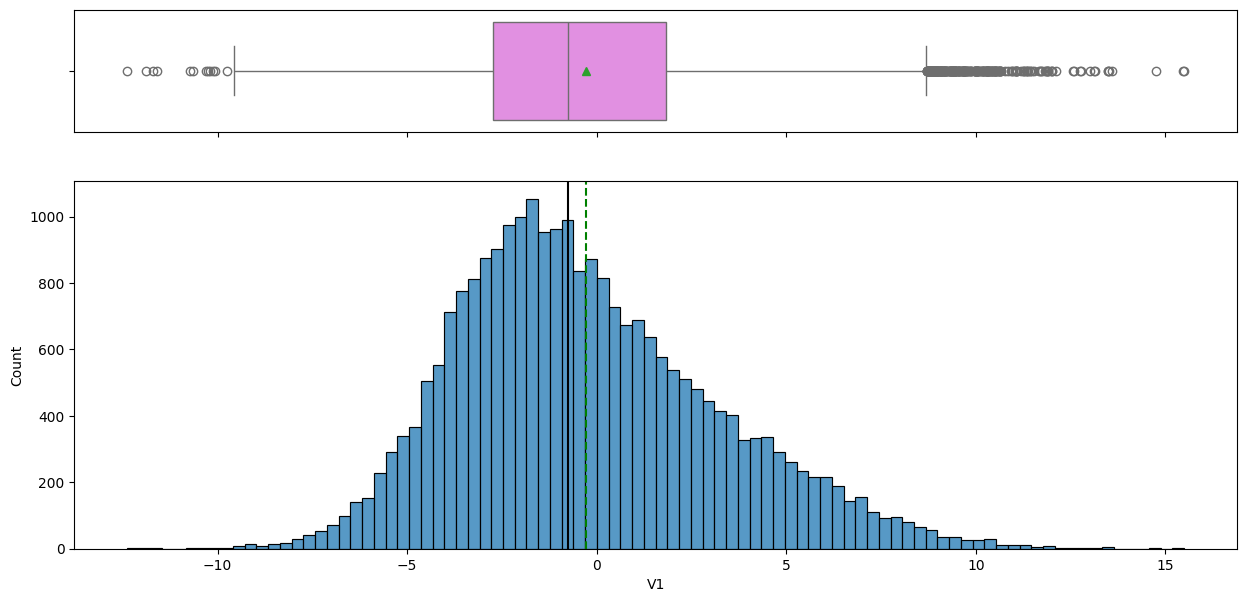

In [ ]:
histogram_boxplot(data,'V1')

- Since the values in V1 is right skewed, choose median for imputing in V1
- We will impute the missing values in V1 before model creation

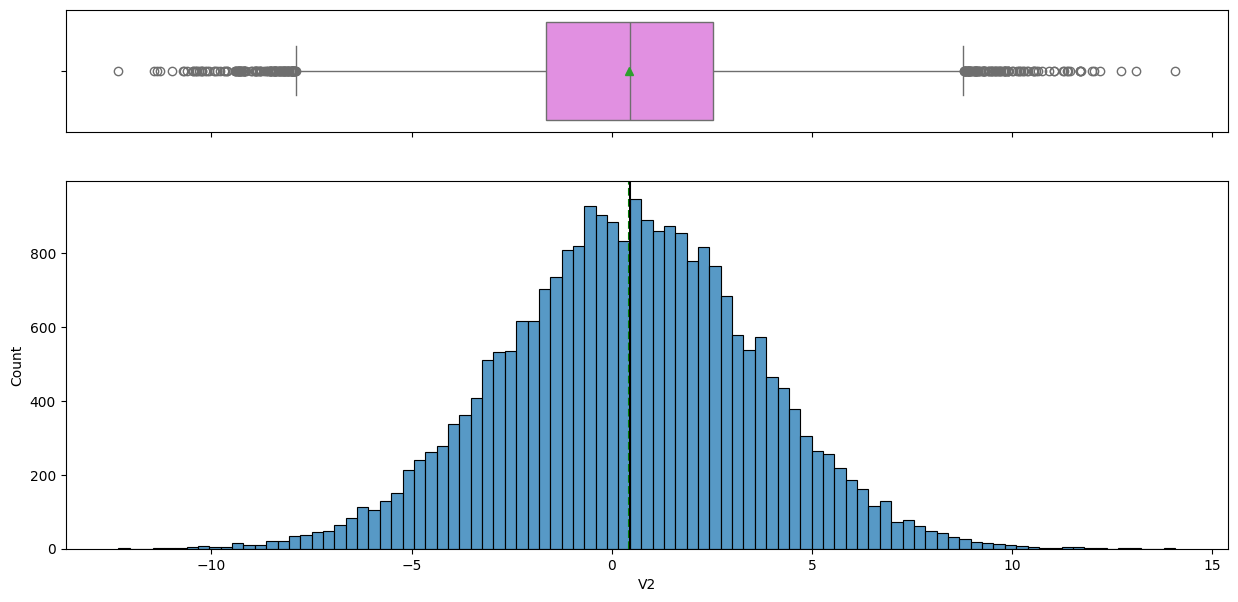

In [ ]:
histogram_boxplot(data,'V2')


* The plot shows a normal distribution, hence use mean for imputing in V2
* We will impute the missing values in V2 before model creation

In [ ]:
# Function to plot histogram
def plot_hist(data,feature,i):
  plt.subplot(9,5,i+1)
  plt.xticks(rotation=45)
  sns.histplot(data,x=feature)


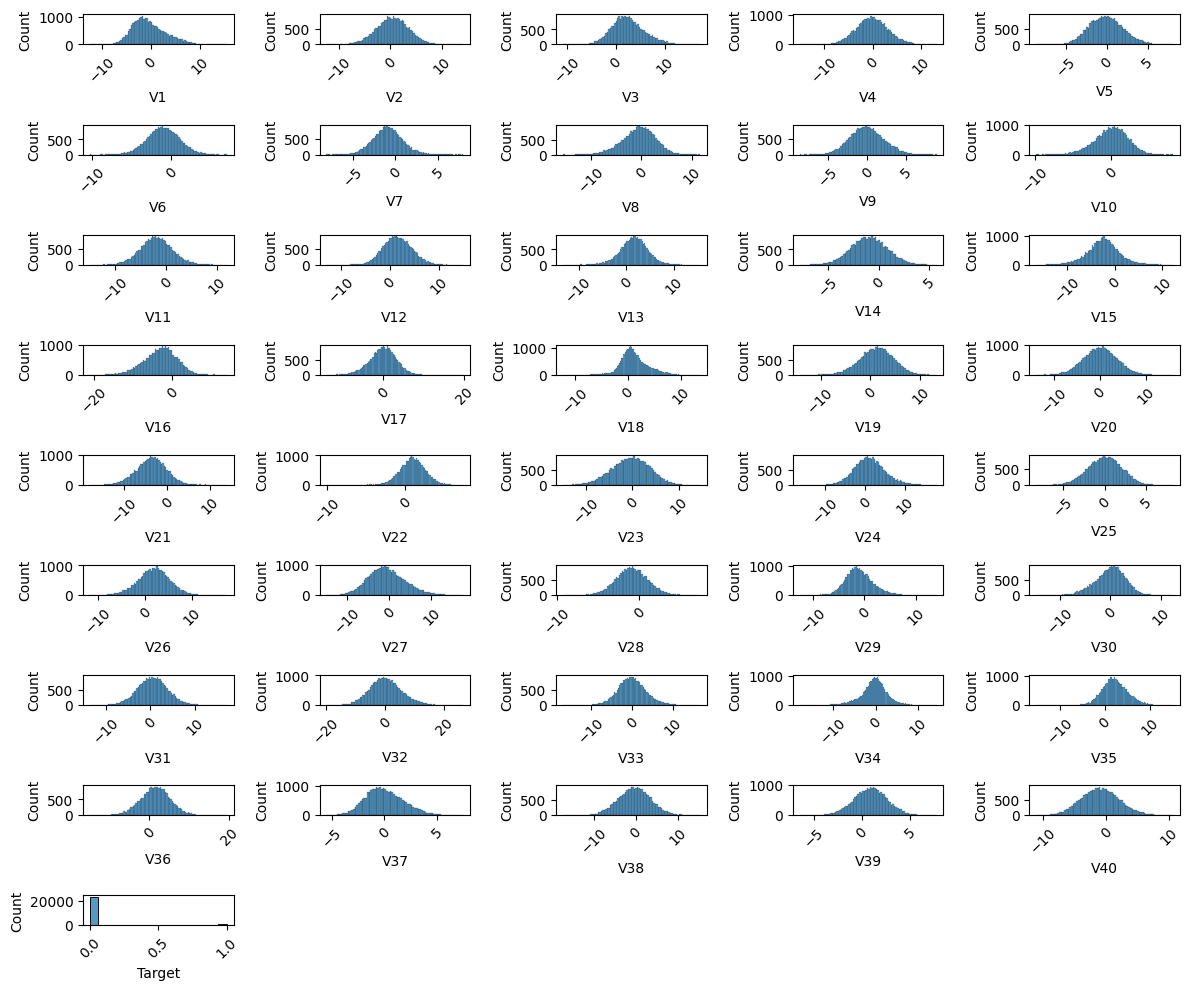

In [ ]:
# Iterate over numerical features

plt.figure(figsize=(12,10))
for i,feature in enumerate(data.columns):
  plot_hist(data,feature,i)
plt.tight_layout()


- Majority of the features have skewness

In [ ]:
# Function to plot box plot
def plot_box(data,feature,i):
  # Define subplots
  plt.subplot(9,5,i+1)
  #plot boxplot
  sns.boxplot(data,x=feature,showmeans=True)


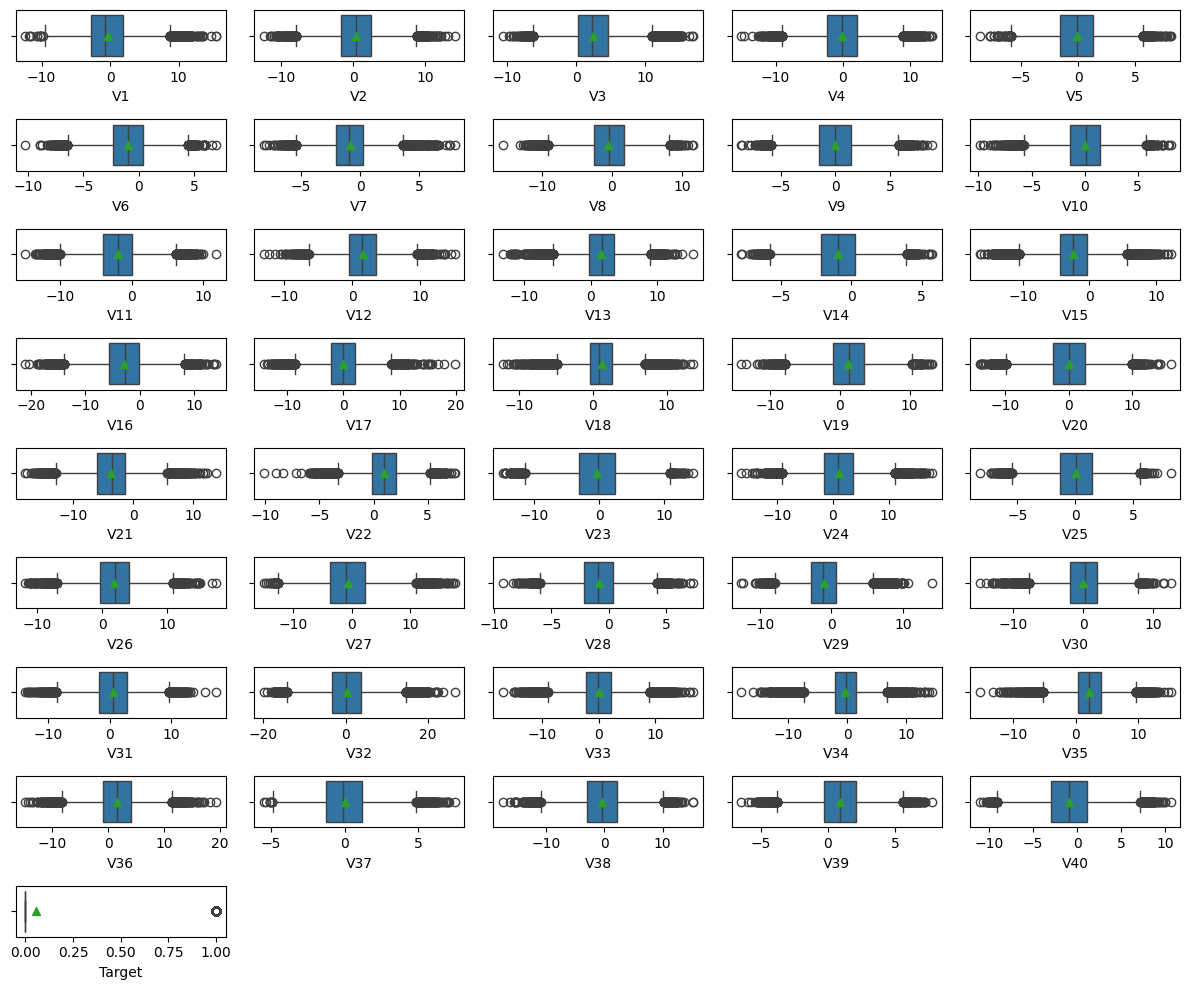

In [ ]:
# Set the figure size
plt.figure(figsize=(12,10))
# Iterate over first a few numerical features
for i,feature in enumerate(data.columns):
  plot_box(data,feature,i,)
plt.tight_layout()


- It seems these features have outliers
- But we don't remove these outliers but consider they are valid data



### Bivariate analysis
#### Find Correlation between the features

<Axes: >

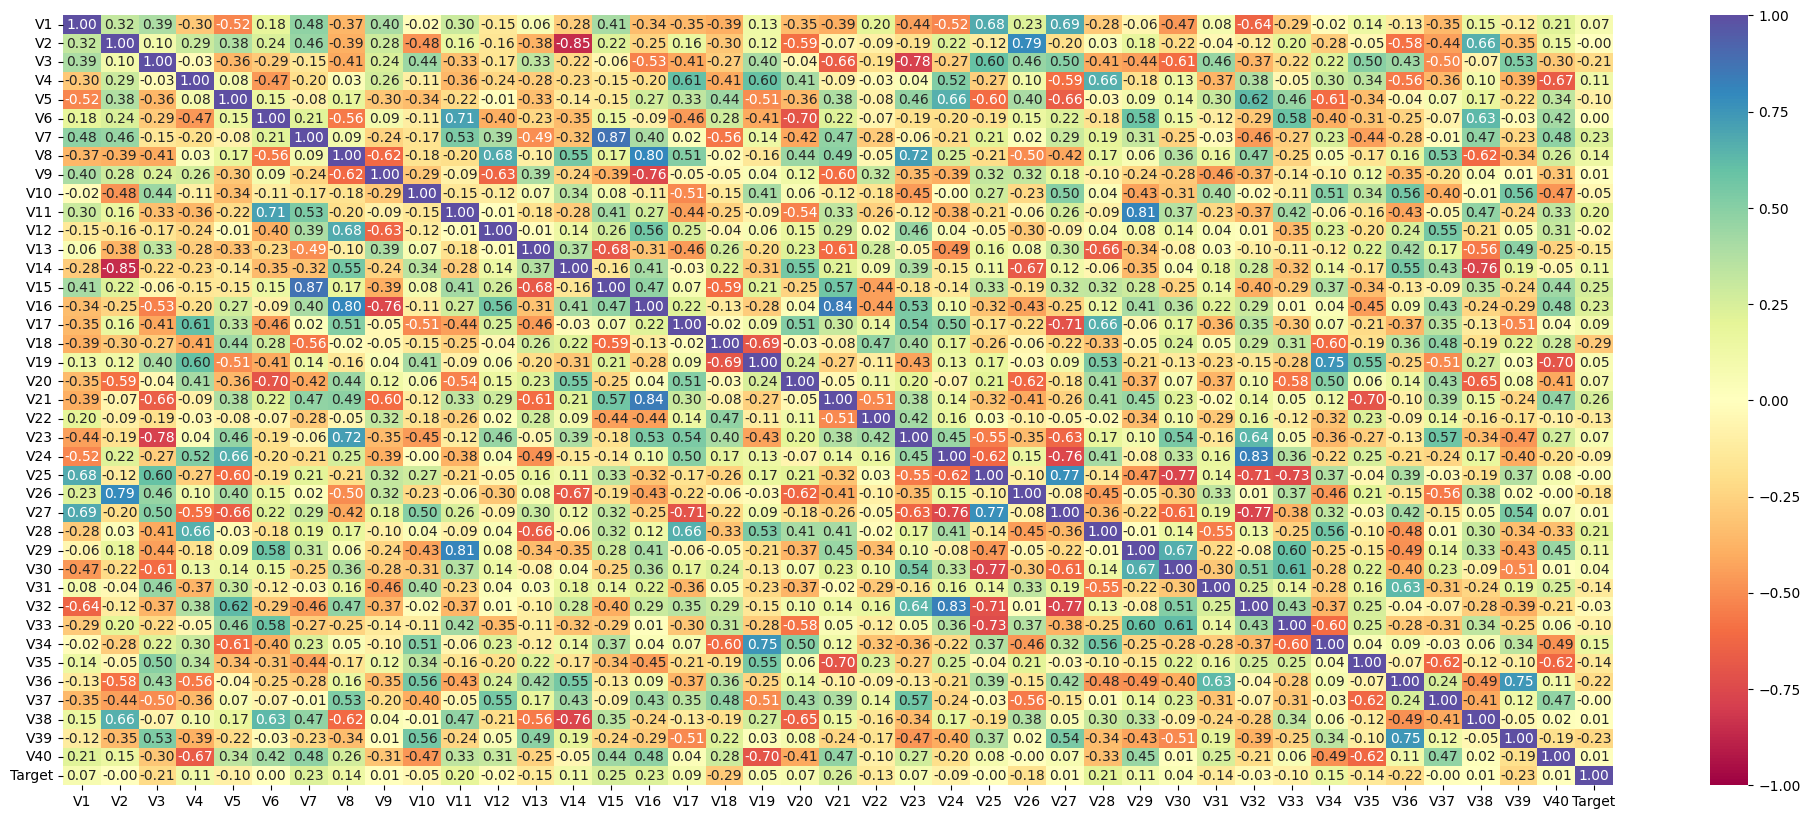

In [ ]:
# Define the size of the plot
plt.figure(figsize=(25,10))
# plotting the heatmap for correlation
sns.heatmap(data.corr(numeric_only=True),annot=True,vmin=-1,vmax=1,fmt="0.2f",cmap="Spectral")

* The feature V18 has a negative correlation(-0.29) with Target feature.
* The feature V21 has a positive correlation(0.26) with the Targat feature
* V14 and V2 seems to have the highest negative correlation

### Visualize the relationships of V18 and V21 wrto Target

[]

<Figure size 1500x1500 with 0 Axes>

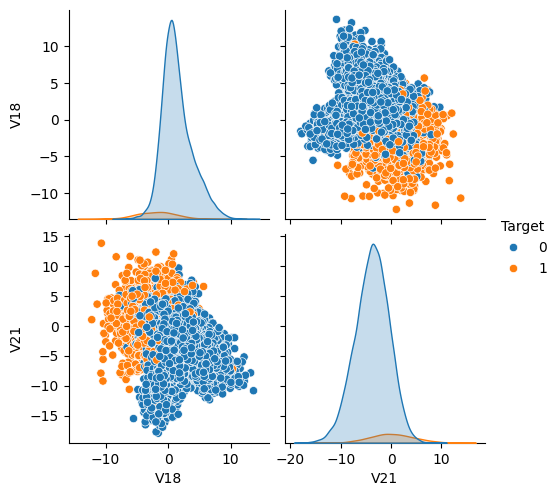

In [ ]:
# Plotting a pairplot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(data[['V18','V21','Target']],hue='Target')
plt.plot()

- The pairplot also proves no significant correlation between numerical features

### Pair Plot on all features and target

In [ ]:
# Plotting a pairplot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(data,hue='Target')
plt.plot()

- The pairplot shows no significant correlation between numerical features
- Couldn't keep the plot due to size limits in the uploads

# Data Preprocessing for Model

In [ ]:
# Copying data to df
df_train = train_org.copy()
df_test=test_org.copy()

In [ ]:
# Save Features and Target in X and y for training
X_train_org = df_train.drop(["Target"], axis=1)
y_train_org= df_train["Target"]


In [ ]:
# Save Features and Target in X and y for testing
X_test = df_test.drop(["Target"], axis=1)
y_test= df_test["Target"]


### Generate Validation test from Test set

---



In [ ]:
# Splitting data  validation and test sets:
# Split train set split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_org, y_train_org, test_size=0.25, random_state=1, stratify=y_train_org
)
print(X_train.shape, X_val.shape, X_test.shape)

(15000, 40) (5000, 40) (5000, 40)


###  Missing value Treatment for V1
* We use median since the distribution is skewed

In [ ]:
# Let's impute the missing values
imp_median = SimpleImputer(missing_values=np.nan, strategy="median")
cols_to_impute = ["V1"]

# fit and transform the imputer on train data
X_train[cols_to_impute] = imp_median.fit_transform(X_train[cols_to_impute])

# Transform on validation
X_val[cols_to_impute] = imp_median.transform(X_val[cols_to_impute])

# Transform on  test data
X_test[cols_to_impute] = imp_median.transform(X_test[cols_to_impute])


###  Missing value Treatment for V2
* We use mean since the distribution is normal

In [ ]:
# Let's impute the missing values
imp_mean = SimpleImputer(missing_values=np.nan, strategy="mean")
cols_to_impute = ["V2"]

# fit and transform the imputer on train data
X_train[cols_to_impute] = imp_mean.fit_transform(X_train[cols_to_impute])

# Transform on validation
X_val[cols_to_impute] = imp_mean.transform(X_val[cols_to_impute])


# Transform on  test data
X_test[cols_to_impute] = imp_mean.transform(X_test[cols_to_impute])


### Normalize the numerical variables

In [ ]:
#Standardizing the numerical variables to zero mean and unit variance.
transformer = StandardScaler()
X_train = transformer.fit_transform(X_train)
X_val = transformer.fit_transform(X_val)
X_test = transformer.fit_transform(X_test)

### Utility Functions

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

# Model Building

**A model can make wrong predictions in the following ways:**
* Predicting a generator failure even when there is no problem with the generator(FP).
* Predicting a generator non-failure but there is a problem with the generator(FN).

**Which case is more important?**

Both cases are actually important for the purposes of this case study.
* False Negatives are real failures which result in replacement cost.
* False Positives will result in inspection costs.

**How to reduce this loss i.e need to reduce False Negatives as well as False Positives?**

Since both errors are important for us to minimize, the company would want the F1 Score evaluation metric to be maximized/ Hence, the focus should be on increasing the F1 score rather than focusing on just one metric i.e. Recall or Precision.


 **As we have are dealing with an imbalance in class distribution, we will be using class weights to allow the model to give proportionally more importance to the minority class.**

In [ ]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587238848108413), 1: np.float64(18.028846153846153)}

In [ ]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 50
batch_size = 64

### Model 0

- Let's start with a neural network consisting of
  - Input Layer with 23 neurons
  - one hidden layer with 15 neurons
  - activation function of ReLU.
  - SGD as the optimizer

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(15,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

* There are 1319 parameters to learn by the model

In [ ]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5386 - loss: 1.1228 - val_accuracy: 0.8708 - val_loss: 0.3842
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8902 - loss: 0.6427 - val_accuracy: 0.9110 - val_loss: 0.2864
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9217 - loss: 0.5466 - val_accuracy: 0.9314 - val_loss: 0.2437
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9359 - loss: 0.4953 - val_accuracy: 0.9424 - val_loss: 0.2203
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9447 - loss: 0.4641 - val_accuracy: 0.9484 - val_loss: 0.2047
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9507 - loss: 0.4412 - val_accuracy: 0.9542 - val_loss: 0.1932
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9549 - loss: 0.4245 - val_accuracy: 0.9582 - val_loss: 0.1866
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9575 - loss: 0.4102 - val_accuracy: 0.

* There are much difference between the validation and training loss
* Accuracy seems to be matching
* We will try to minimise these differences and loss later on using different models.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  41.87007808685303


#### Plotting Loss

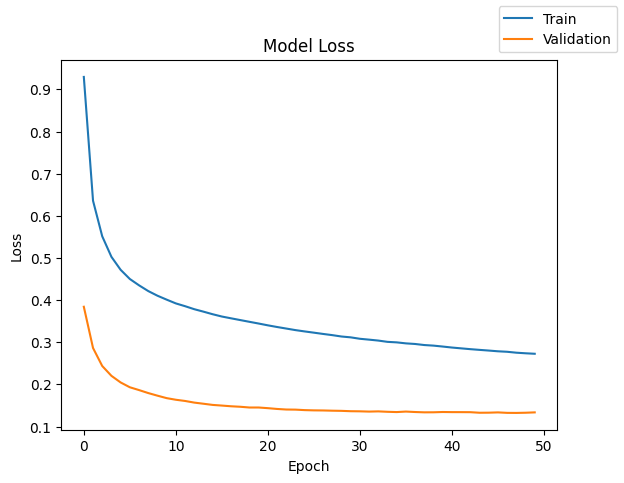

In [ ]:
plot(history,'loss')

* Train and validation loss scores  tend to converge after 20 epoch but shows much differences in scores.
* Validation loss is less than the train loss.


#### Plotting Accuracy

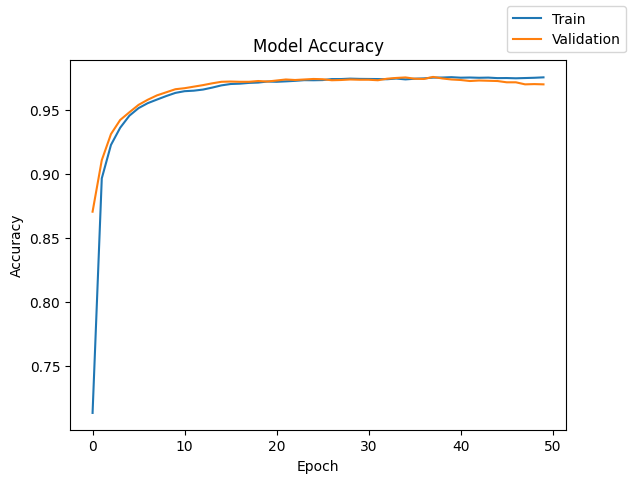

In [ ]:
plot(history,'accuracy')

* Validation accuracy scores shows decreasing as epochs increases
* validation accuracy was greater than training until epoch 10
* Both converges after epoch 30, but still slight variation in validation accuracy

In [ ]:
model_0_train_perf = model_performance_classification(model, X_train, y_train)
model_0_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.973933,0.973933,0.979419,0.975665


In [ ]:
model_0_val_perf = model_performance_classification(model, X_val, y_val)
model_0_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9702,0.9702,0.975271,0.971966


#### Define a dataframe results to save the results

In [ ]:

columns=['## hidden layers','# neurons - hidden layer','activation fn-hidden layer', '#epochs','batch_size','optimizer','learning rate, momentum','weight initializer','regularization','train F1','val F1','train loss','validation loss','train accuracy','validation accuracy','time']
results=pd.DataFrame(columns=columns)

In [ ]:

results.loc[0] = [1, [15], ["relu", "relu"], 50, 64, "sgd", [0.001, "-"], "xavier", "-", model_0_train_perf['F1 Score'][0].item(),model_0_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078


* The results are good with SGD but in the initial few epochs, it takes some time to improve.
* The validation loss is less than the training loss.
* We can add a momentum to SGD to see if the results improves
* The momentum term accelerates the optimization process by adding a fraction of the previous update to the current update
* This will enable faster convergence and reduced oscillations in the loss across epochs
* F1 score is almost same in Train and Validation
- Train F1 score of ~0.97 and test F1 score of ~0.97 indicate consistent performance of the model between training and validation datasets.
- Even though it's a good score, the rate of improvement over the epochs is still low.


**We will add a momentum to SGD to see the difference and to increase the rate of improvement**

### Model 1

- Let's start with a neural network consisting of
  - input layer with 23  and a hidden layer with 15 neurons respectively
  - activation function of ReLU.
  - SGD as the optimizer
  - Add Momentum to SGD

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(15,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

* There are 1319 parameters to learn by the model

In [ ]:
moment=0.09 # Define momentum
optimizer = tf.keras.optimizers.SGD(momentum=moment)    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6105 - loss: 1.0822 - val_accuracy: 0.8692 - val_loss: 0.3588
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8875 - loss: 0.6321 - val_accuracy: 0.9164 - val_loss: 0.2639
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9242 - loss: 0.5315 - val_accuracy: 0.9358 - val_loss: 0.2272
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9402 - loss: 0.4777 - val_accuracy: 0.9444 - val_loss: 0.2074
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9496 - loss: 0.4434 - val_accuracy: 0.9510 - val_loss: 0.1943
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9539 - loss: 0.4207 - val_accuracy: 0.9556 - val_loss: 0.1856
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9571 - loss: 0.4047 - val_accuracy: 0.9580 - val_loss: 0.1794
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.3916 - val_accuracy: 0.

* Validation loss is still less than training loss
* Training and Validation accuracy is matching


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  42.340718030929565


#### Plotting Loss

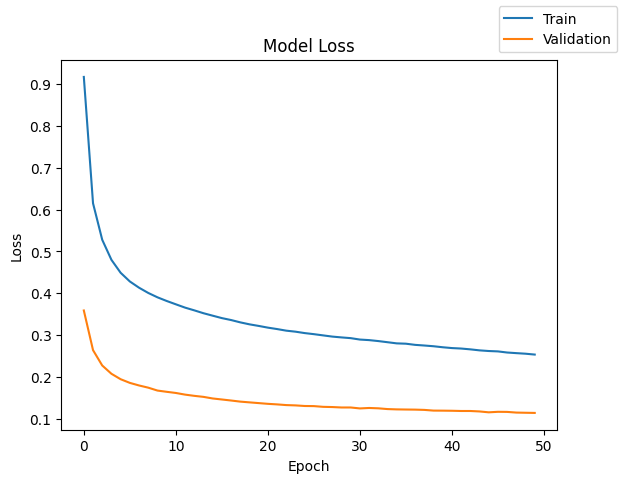

In [ ]:
plot(history,'loss')

* Train and validation loss scores  tend to converge after 20 epoch but shows significant differences in scores.
* Validation loss is less than the train loss
* The difference between both losses is quite large

#### Plotting Accuracy

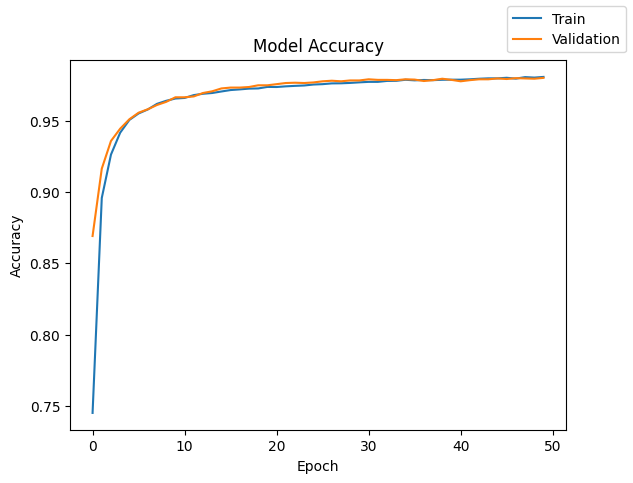

In [ ]:
plot(history,'accuracy')


* Validation and Training accuracy converges after epoch 30 and validation accuracy has not much variations
* Validation accuracy is greater than training after epoch 35


In [ ]:
model_1_train_perf = model_performance_classification(model, X_train, y_train)
model_1_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.980733,0.980733,0.983562,0.981634


In [ ]:
model_1_val_perf = model_performance_classification(model, X_val, y_val)
model_1_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98,0.98,0.981412,0.98054


#### Save  the results in dataframe

In [ ]:

results.loc[1] = [1, [15], ["relu", "relu"], 50, 64, "sgd", [0.001, "-"], "xavier", "-", model_1_train_perf['F1 Score'][0].item(),model_1_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718


* The train loss has increased compared to model 0
* F1 score of Train has increased a bit than Validation in Model 1
* Model 1 took longer than Model 0
* Adding momentum didnt improve the rate of improvements in convergence
* As expected training and validation performance scores improved than Model 0
* Let's add adaptive optimizer Adam

### Model 2
* Let's change the optimizer to Adam
   * This will introduce momentum as well as an adaptive learning rate

- Let's start with a neural network consisting of
  - two hidden layers with 23 and 15 neurons respectively
  - activation function of ReLU.
  - Adam as the optimizer
  

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(15,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

* There are 1319 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8224 - loss: 1.0093 - val_accuracy: 0.8716 - val_loss: 0.3367
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9108 - loss: 0.5655 - val_accuracy: 0.9116 - val_loss: 0.2690
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9396 - loss: 0.4631 - val_accuracy: 0.9326 - val_loss: 0.2299
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9549 - loss: 0.4090 - val_accuracy: 0.9446 - val_loss: 0.2074
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9627 - loss: 0.3742 - val_accuracy: 0.9550 - val_loss: 0.1926
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9687 - loss: 0.3501 - val_accuracy: 0.9620 - val_loss: 0.1821
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.3343 - val_accuracy: 0.9654 - val_loss: 0.1736
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.3222 - val_accuracy: 0.

* Validation loss is still less than training loss
* Training accuracy is greater than validation accuracy


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  42.48967790603638


#### Plotting Loss

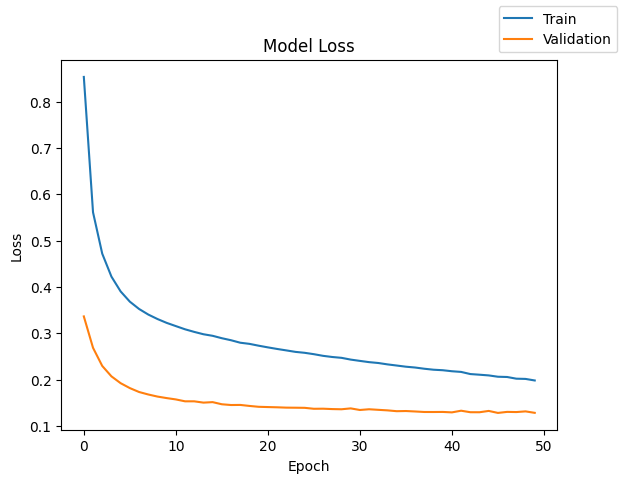

In [ ]:
plot(history,'loss')

* Train and validation loss scores  tend to converge after 20 epochs.
* Validation loss is less than the train loss, but seems difference decreased compared to two previous models.

#### Plotting Accuracy

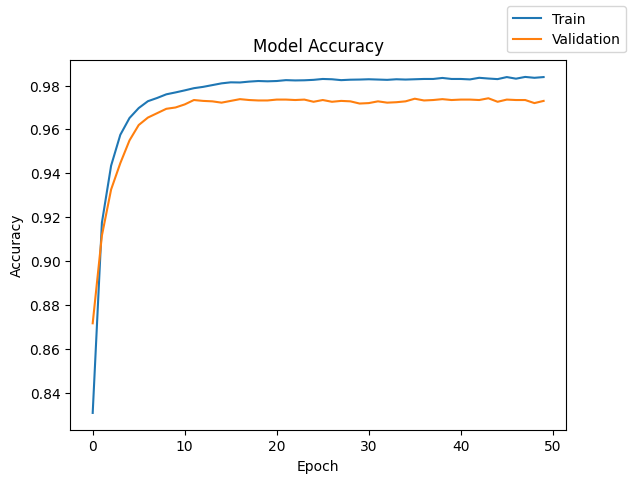

In [ ]:
plot(history,'accuracy')

* Validation accuracy scores shows decreasing as epochs increases
* Training accuracy is greater than validation accuracy
* Both converges after epoch 30 and validation accuracy shows variations

In [ ]:
model_2_train_perf = model_performance_classification(model, X_train, y_train)
model_2_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.978,0.978,0.982376,0.97933


In [ ]:
model_2_val_perf = model_performance_classification(model, X_val, y_val)
model_2_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.973,0.973,0.977093,0.974426


#### Save  the results in dataframe

In [ ]:
results.loc[2] = [1, [15], ["relu", "relu"], 50, 64, "adam", [0.001, "-"], "xavier", "-", model_2_train_perf['F1 Score'][0].item(),model_2_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718
2,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.979330,0.974426,0.198491,0.128654,0.983867,0.9730,42.489678


* The train loss of model 2 has decreased.
* Model 2 took longer than previous models
* F1 scores has decreased in Model 2
* The difference between train and validation loss is decreased but not so much
* We will add dropout to see if the results improves

### Model 3
* Let's add dropout to reguralize the loss differences between train and valid
   * add 0.5 and 0.2 dropouts in the hidden layers

- Let's start with a neural network consisting of
  - two hidden layers with 23 and 15 neurons respectively
  - activation function of ReLU.
  - Adam as the optimizer
  

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.5))
model.add(Dense(15,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

* There are 1319 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4916 - loss: 1.4734 - val_accuracy: 0.8158 - val_loss: 0.4375
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7549 - loss: 0.9248 - val_accuracy: 0.8838 - val_loss: 0.3439
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8357 - loss: 0.8064 - val_accuracy: 0.9306 - val_loss: 0.2725
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.7050 - val_accuracy: 0.9462 - val_loss: 0.2442
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8903 - loss: 0.6519 - val_accuracy: 0.9510 - val_loss: 0.2313
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9076 - loss: 0.6287 - val_accuracy: 0.9524 - val_loss: 0.2211
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9180 - loss: 0.6029 - val_accuracy: 0.9554 - val_loss: 0.2130
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9234 - loss: 0.5683 - val_accuracy: 0.

* Validation loss is still less than training loss
* Validation accuracy is greater than training accuracy


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  45.741116523742676


#### Plotting Loss

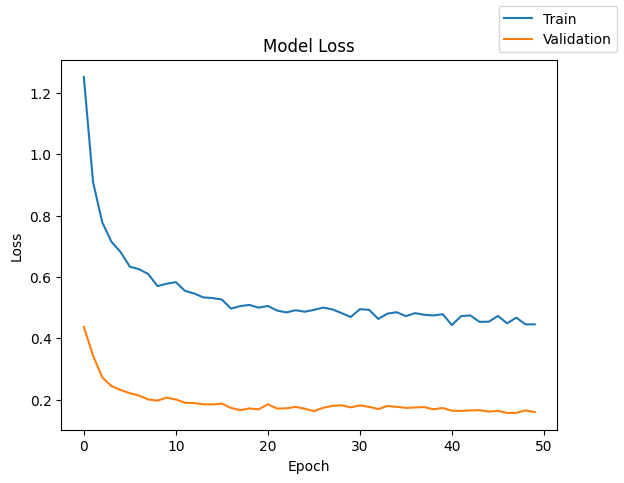

In [ ]:
plot(history,'loss')


* Validation loss is less than the train loss, but seems difference has increased
* Both losses has high variations

#### Plotting Accuracy

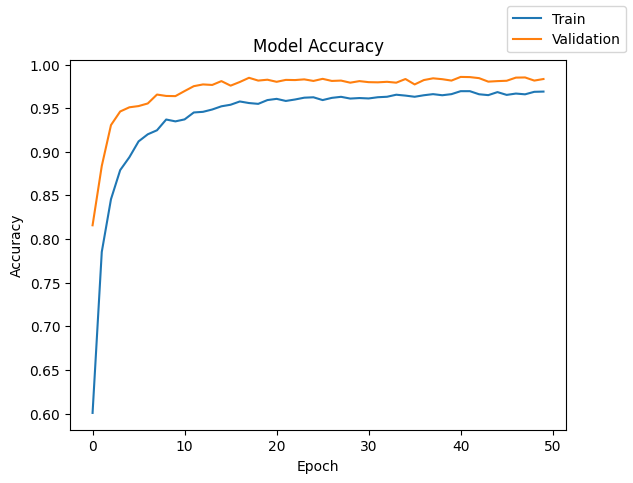

In [ ]:
plot(history,'accuracy')

* Validation accuracy scores shows increasing as epochs increases
* Validation accuracy is greater than the training accuracy and both shows a lot of fluctuations.


In [ ]:
model_3_train_perf = model_performance_classification(model, X_train, y_train)
model_3_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986333,0.986333,0.986703,0.986488


In [ ]:
model_3_val_perf = model_performance_classification(model, X_val, y_val)
model_3_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9834,0.9834,0.98381,0.983578


#### Save  the results in dataframe

In [ ]:

results.loc[3] = [1, [15], ["relu", "relu"], 50, 64, "adam", [0.001, "-"], "xavier", "-", model_3_train_perf['F1 Score'][0].item(),model_3_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718
2,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.979330,0.974426,0.198491,0.128654,0.983867,0.9730,42.489678
3,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.986488,0.983578,0.445556,0.159413,0.969000,0.9834,45.741117


* Model 3 took longer than previous models.
* F1 score of train and validation have been increased to 98%
* The differences between loss on train and validation has increased
* Hence we will add batch normalization to see the result improves or not

### Model 4
* Let's add Batch Normalization
   * Add Batch Normalization to one of the hidden layers and output layer

- Let's start with a neural network consisting of
  - two hidden layers with 23 and 15 neurons respectively
  - activation function of ReLU.
  - Adam as the optimizer
  

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dense(15,activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23)             │            92 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15)             │            60 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,471 (5.75 KB)

 Trainable params: 1,395 (5.45 KB)

 Non-trainable params: 76 (304.00 B)

* There are 1395 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6534 - loss: 1.0550 - val_accuracy: 0.9248 - val_loss: 0.3389
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8985 - loss: 0.5651 - val_accuracy: 0.9538 - val_loss: 0.2207
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.4586 - val_accuracy: 0.9608 - val_loss: 0.1864
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9500 - loss: 0.4151 - val_accuracy: 0.9644 - val_loss: 0.1694
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9554 - loss: 0.3911 - val_accuracy: 0.9680 - val_loss: 0.1575
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9582 - loss: 0.3740 - val_accuracy: 0.9700 - val_loss: 0.1508
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9612 - loss: 0.3588 - val_accuracy: 0.9700 - val_loss: 0.1472
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9633 - loss: 0.3439 - val_accuracy: 0.

* Validation loss is still less than training loss
* Training accuracy has increased to a small extend


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  51.856202840805054


#### Plotting Loss

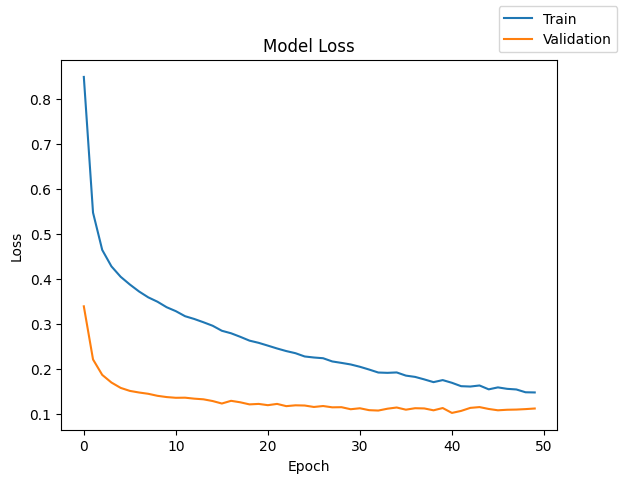

In [ ]:
plot(history,'loss')


* Validation loss is less than the train loss, but seems  difference has decreased
* Both losses has some variations

#### Plotting Accuracy

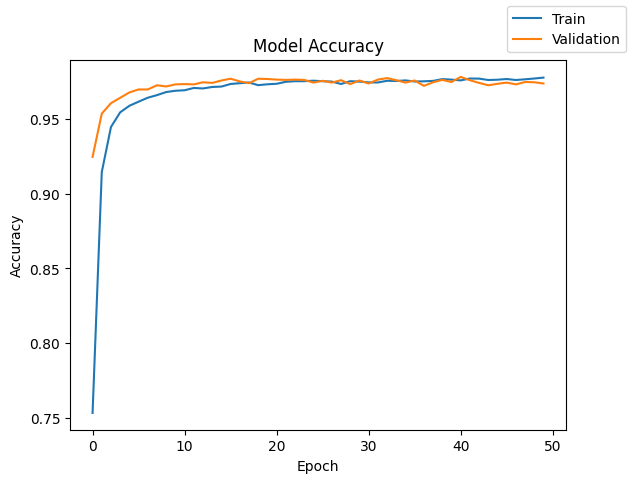

In [ ]:
plot(history,'accuracy')

* Both accuracy values tends to matching as epoches increases
* Training accuracy is greater than validation at epoch 50


In [ ]:
model_4_train_perf = model_performance_classification(model, X_train, y_train)
model_4_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9792,0.9792,0.982454,0.980242


In [ ]:
model_4_val_perf = model_performance_classification(model, X_val, y_val)
model_4_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.974,0.974,0.977283,0.975183


#### Save  the results in dataframe

In [ ]:

results.loc[4] = [1, [15], ["relu", "relu"], 50, 64, "adam", [0.001, "-"], "xavier", "-", model_4_train_perf['F1 Score'][0].item(),model_4_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718
2,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.979330,0.974426,0.198491,0.128654,0.983867,0.9730,42.489678
3,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.986488,0.983578,0.445556,0.159413,0.969000,0.9834,45.741117
4,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.980242,0.975183,0.147313,0.111607,0.977933,0.9740,51.856203


* The difference between training and validation loss has decreased
* Training accuracy has increased compared to validation accuracy
* A decreasing loss gap usually indicates less overfitting.


### Model 5
* Let's add both Batch Normalization and drop out
   

- Let's start with a neural network consisting of
  - two hidden layers with 23 and 15 neurons respectively
  - activation function of ReLU.
  - Adam as the optimizer
  

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(15,activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23)             │            92 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15)             │            60 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,471 (5.75 KB)

 Trainable params: 1,395 (5.45 KB)

 Non-trainable params: 76 (304.00 B)

* There are 1395 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5059 - loss: 1.5567 - val_accuracy: 0.7568 - val_loss: 0.5424
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7153 - loss: 0.9607 - val_accuracy: 0.8690 - val_loss: 0.3806
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8238 - loss: 0.8245 - val_accuracy: 0.8966 - val_loss: 0.3151
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.7494 - val_accuracy: 0.9018 - val_loss: 0.2992
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8725 - loss: 0.6682 - val_accuracy: 0.9150 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8840 - loss: 0.6598 - val_accuracy: 0.9304 - val_loss: 0.2351
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8956 - loss: 0.6263 - val_accuracy: 0.9424 - val_loss: 0.2151
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8981 - loss: 0.6253 - val_accuracy: 0.

* Validation loss is still less than training loss
* Training accuracy has decreased and validation accuracy increased, shows a large difference between Training and Validation


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  55.6161835193634


#### Plotting Loss

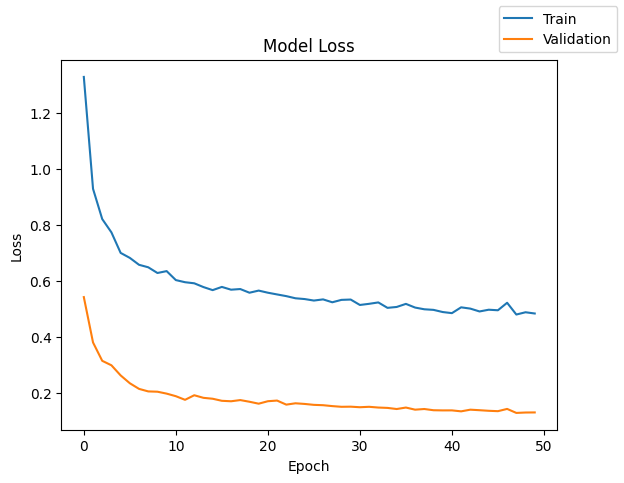

In [ ]:
plot(history,'loss')


* Validation loss is less than the train loss, but seems  difference has increased
* Both losses has some variations

#### Plotting Accuracy

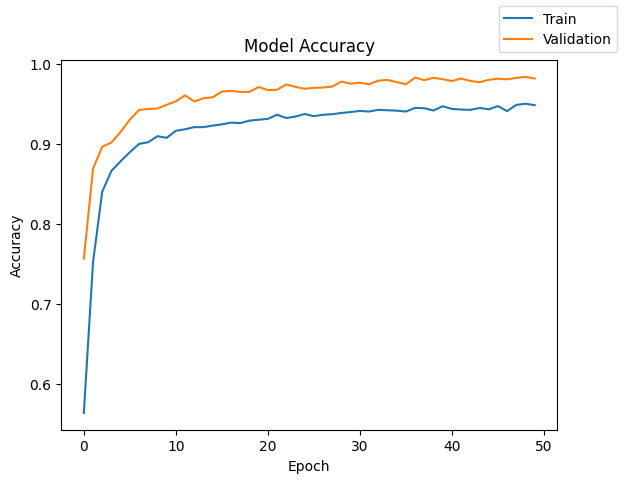

In [ ]:
plot(history,'accuracy')

* The difference between training accuracy and validation accuracy has increased
* Validation accuracy is greater than training since we applied regularization techniques such as drop out and batch normalization

In [ ]:
model_5_train_perf = model_performance_classification(model, X_train, y_train)
model_5_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.983933,0.983933,0.984855,0.984283


In [ ]:
model_5_val_perf = model_performance_classification(model, X_val, y_val)
model_5_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9816,0.9816,0.982241,0.981871


#### Save  the results in dataframe

In [ ]:

results.loc[5] = [1, [15], ["relu", "relu"], 50, 64, "adam", [0.001, "-"], "xavier", "-", model_5_train_perf['F1 Score'][0].item(),model_5_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718
2,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.979330,0.974426,0.198491,0.128654,0.983867,0.9730,42.489678
3,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.986488,0.983578,0.445556,0.159413,0.969000,0.9834,45.741117
4,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.980242,0.975183,0.147313,0.111607,0.977933,0.9740,51.856203
5,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.984283,0.981871,0.483917,0.131047,0.948333,0.9816,55.616184


* The difference between training and validation loss has increased
* An increasing loss gap usually indicates  overfitting.


### Model 6
- Let's initialize the weights using He normal.
- We'll also use only Dropout for regularization.

- Let's start with a neural network consisting of
  - two hidden layers with 23 and 15 neurons respectively
  - activation function of ReLU.
  - Adam as the optimizer
  

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",kernel_initializer="he_normal",input_dim=X_train.shape[1]))
model.add(Dropout(0.5))
model.add(Dense(15,activation="relu",kernel_initializer="he_normal"))
model.add(Dropout(0.2))
model.add(Dense(1,activation="sigmoid",kernel_initializer="he_normal"))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

* There are 1319 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2790 - loss: 1.8298 - val_accuracy: 0.8310 - val_loss: 0.5065
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7262 - loss: 0.9988 - val_accuracy: 0.8786 - val_loss: 0.3885
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8311 - loss: 0.8410 - val_accuracy: 0.9056 - val_loss: 0.3261
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8593 - loss: 0.7424 - val_accuracy: 0.9238 - val_loss: 0.2853
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.7321 - val_accuracy: 0.9294 - val_loss: 0.2699
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9046 - loss: 0.6498 - val_accuracy: 0.9426 - val_loss: 0.2445
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.6594 - val_accuracy: 0.9504 - val_loss: 0.2456
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9168 - loss: 0.6269 - val_accuracy: 0.

* Validation loss is still less than training loss
* Training accuracy has decreased and validation accuracy increased, shows a small difference between Training and Validation


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  66.95959639549255


#### Plotting Loss

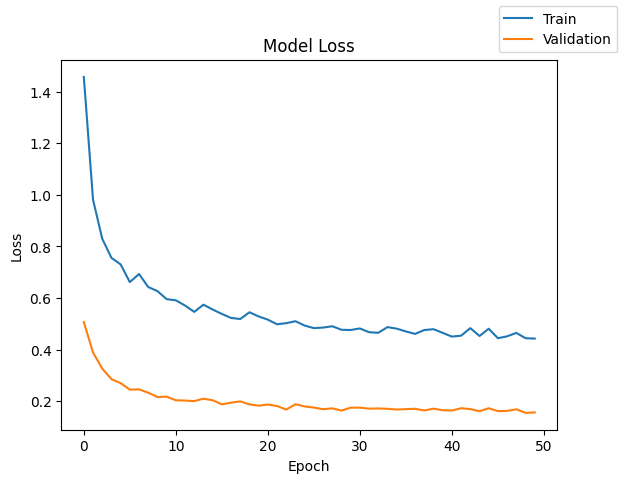

In [ ]:
plot(history,'loss')


* Validation loss is less than the train loss, but seems  difference has increased
* Both losses has some variations

#### Plotting Accuracy

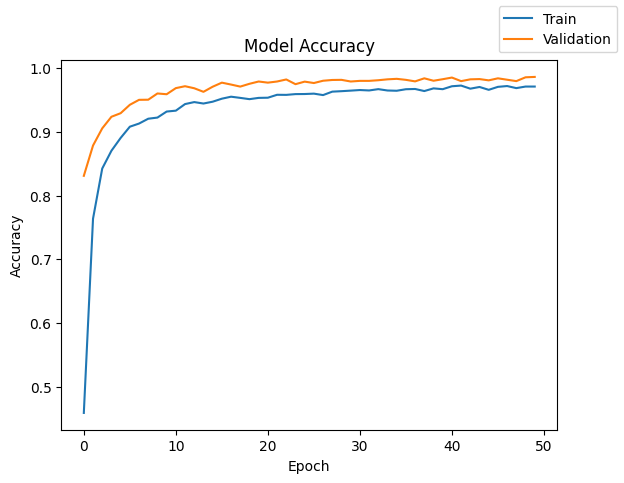

In [ ]:
plot(history,'accuracy')

* The difference between training accuracy and validation accuracy has decreased
* Validation accuracy is greater than training since we applied regularization techniques such as drop out

In [ ]:
model_6_train_perf = model_performance_classification(model, X_train, y_train)
model_6_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986933,0.986933,0.987184,0.987042


In [ ]:
model_6_val_perf = model_performance_classification(model, X_val, y_val)
model_6_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9864,0.9864,0.986273,0.98633


#### Save  the results in dataframe

In [ ]:

results.loc[6] = [1, [15], ["relu", "relu"], 50, 64, "adam", [0.001, "-"], "xavier", "-", model_6_train_perf['F1 Score'][0].item(),model_6_val_perf['F1 Score'][0].item(),history.history["loss"] [-1],history.history["val_loss"] [-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],end-start]

In [ ]:
results

,## hidden layers,# neurons - hidden layer,activation fn-hidden layer,#epochs,batch_size,optimizer,"learning rate, momentum",weight initializer,regularization,train F1,val F1,train loss,validation loss,train accuracy,validation accuracy,time
0,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.975665,0.971966,0.272697,0.133646,0.975667,0.9702,41.870078
1,1,[15],"[relu, relu]",50,64,sgd,"[0.001, -]",xavier,-,0.981634,0.980540,0.253304,0.113662,0.980667,0.9800,42.340718
2,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.979330,0.974426,0.198491,0.128654,0.983867,0.9730,42.489678
3,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.986488,0.983578,0.445556,0.159413,0.969000,0.9834,45.741117
4,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.980242,0.975183,0.147313,0.111607,0.977933,0.9740,51.856203
5,1,[15],"[relu, relu]",50,64,adam,"[0.001, -]",xavier,-,0.984283,0.981871,0.483917,0.131047,0.948333,0.9816,55.616184


* The difference between training and validation loss has increased, the model shows signs of overfitting
* An increasing loss gap usually indicates  overfitting.
* F1 scores has increased for both validation and traing set

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Neural Network (SGD, No Regularization)",
    "Neural Network (SGD with Momentum, No Regularization)",
    "Neural Network (Adam , No Regularization)",
    "Neural Network (Adam, dropout [0.5,0.2])",
    "Neural Network (Adam, Batch Normalization)",
    "Neural Network (dropout [0.5,0.2], Batch Normalization)",
    "Neural Network (Adam,dropout [0.5,0.2] ,He initialization)"
]

In [ ]:
#Validation performance comparison

models_valid_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T
    ],
    axis=1,
)
models_valid_comp_df.columns = [
    "Neural Network (SGD, No Regularization)",
    "Neural Network (SGD with Momentum, No Regularization)",
    "Neural Network (Adam , No Regularization)",
    "Neural Network (Adam, dropout [0.5,0.2])",
    "Neural Network (Adam, Batch Normalization)",
    "Neural Network (dropout [0.5,0.2], Batch Normalization)",
    "Neural Network (Adam,dropout [0.5,0.2] ,He initialization)"
]

In [ ]:
models_train_comp_df

,"Neural Network (SGD, No Regularization)","Neural Network (SGD with Momentum, No Regularization)","Neural Network (Adam , No Regularization)","Neural Network (Adam, dropout [0.5,0.2])","Neural Network (Adam, Batch Normalization)","Neural Network (dropout [0.5,0.2], Batch Normalization)","Neural Network (Adam,dropout [0.5,0.2] ,He initialization)"
Accuracy,0.973933,0.980733,0.978000,0.986333,0.979200,0.983933,0.986933
Recall,0.973933,0.980733,0.978000,0.986333,0.979200,0.983933,0.986933
Precision,0.979419,0.983562,0.982376,0.986703,0.982454,0.984855,0.987184
F1 Score,0.975665,0.981634,0.979330,0.986488,0.980242,0.984283,0.987042


In [ ]:
models_valid_comp_df

,"Neural Network (SGD, No Regularization)","Neural Network (SGD with Momentum, No Regularization)","Neural Network (Adam , No Regularization)","Neural Network (Adam, dropout [0.5,0.2])","Neural Network (Adam, Batch Normalization)","Neural Network (dropout [0.5,0.2], Batch Normalization)","Neural Network (Adam,dropout [0.5,0.2] ,He initialization)"
Accuracy,0.970200,0.980000,0.973000,0.983400,0.974000,0.981600,0.986400
Recall,0.970200,0.980000,0.973000,0.983400,0.974000,0.981600,0.986400
Precision,0.975271,0.981412,0.977093,0.983810,0.977283,0.982241,0.986273
F1 Score,0.971966,0.980540,0.974426,0.983578,0.975183,0.981871,0.986330


In [ ]:
models_train_comp_df.loc["F1 Score"] - models_valid_comp_df.loc["F1 Score"]

,F1 Score
"Neural Network (SGD, No Regularization)",0.003699
"Neural Network (SGD with Momentum, No Regularization)",0.001094
"Neural Network (Adam , No Regularization)",0.004903
"Neural Network (Adam, dropout [0.5,0.2])",0.002910
"Neural Network (Adam, Batch Normalization)",0.005059
"Neural Network (dropout [0.5,0.2], Batch Normalization)",0.002412
"Neural Network (Adam,dropout [0.5,0.2] ,He initialization)",0.000712


- Final Model: **Neural Network (Adam, Batch Normalization)**
- Reasoning:
  - Best F1 score on the training set (~0.98), indicating strong performance in learning from the training data.
  - Best F1 score on the validation set (~0.97), demonstrating good performance in generalizing to unseen data.
  - This model has the highest F1 score, meaning it achieves the best balance of precision and recall among all configurations
  - The difference between training loss and validation loss is also less

### Final Model

### Model 4


In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model = Sequential()
model.add(Dense(23,activation="relu",input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dense(15,activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │           943 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23)             │            92 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15)             │            60 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,471 (5.75 KB)

 Trainable params: 1,395 (5.45 KB)

 Non-trainable params: 76 (304.00 B)

* There are 1395 parameters to learn by the model

In [ ]:

optimizer = tf.keras.optimizers.Adam(0.001)   # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])

In [ ]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6536 - loss: 1.0004 - val_accuracy: 0.9220 - val_loss: 0.2991
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9067 - loss: 0.5423 - val_accuracy: 0.9552 - val_loss: 0.2015
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9456 - loss: 0.4432 - val_accuracy: 0.9630 - val_loss: 0.1754
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9550 - loss: 0.3959 - val_accuracy: 0.9678 - val_loss: 0.1557
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9594 - loss: 0.3630 - val_accuracy: 0.9704 - val_loss: 0.1493
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9609 - loss: 0.3450 - val_accuracy: 0.9714 - val_loss: 0.1417
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9643 - loss: 0.3305 - val_accuracy: 0.9716 - val_loss: 0.1378
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9669 - loss: 0.3177 - val_accuracy: 0.

In [ ]:
y_train_pred = model.predict(X_train)
y_valid_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("Classification Report - Train data",end="\n\n")
cr = classification_report(y_train,y_train_pred>0.5)
print(cr)

Classification Report - Train data

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14168
           1       0.75      0.93      0.83       832

    accuracy                           0.98     15000
   macro avg       0.87      0.96      0.91     15000
weighted avg       0.98      0.98      0.98     15000



In [ ]:
print("Classification Report - Validation data",end="\n\n")
cr = classification_report(y_val,y_valid_pred>0.5)
print(cr)

Classification Report - Validation data

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4722
           1       0.69      0.88      0.77       278

    accuracy                           0.97      5000
   macro avg       0.84      0.93      0.88      5000
weighted avg       0.98      0.97      0.97      5000



In [ ]:
print("Classification Report - Test data",end="\n\n")
cr = classification_report(y_test,y_test_pred>0.5)
print(cr)

Classification Report - Test data

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4718
           1       0.70      0.86      0.77       282

    accuracy                           0.97      5000
   macro avg       0.85      0.92      0.88      5000
weighted avg       0.98      0.97      0.97      5000



- The weighted F1 score on the test data is ~0.97

- An F1 score of ~0.97 indicates a good balance between precision and recall, suggesting moderate performance in accurately classifying instances with minimal false positives and false negatives.

- Model can be further tuned to deal with minority class.

## Business Insights and Recommendations

* The ReneWind company can deploy the final model from this exercise to identify with a reasonable degree of accuracy whether the generator is likely to fail or not, and this process seems to be easier and more time-efficient than other methods.

- The company should also consider generators age, environments change which adversly affect the model performance. Hence
  - Track F1, precision, recall monthly.
  - Set up alerts if F1 drops below 0.8 (or target threshold).
  - Retrain with new data every 3–6 months.

- Company can  combine with Human Expertise. Use model as “first filter” — engineers investigate top 10% highest-risk units and collect the feedback on Model prediction: Was prediction correct/wrong? What is the reason?. Train the model according to this feedback to improve its performance.


- During post training Ml engineer can employ techniques like oversampling minority classes, using appropriate evaluation metrics (e.g., F1-score), or employing ensemble methods like SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance. Ensuring a balanced dataset is crucial for model training to avoid biased predictions.